<a href="https://colab.research.google.com/github/augustodalosta-lgtm/HTI--Hydro-Thermal-Index-Data-Center/blob/main/Hydrothermal_Index_Aug_Dalosta_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# HTI — Hydrothermal Index
# Métrica de Viabilidade Climática para Data Centers Tropicais
# Autor: Augusto dos Santos Dalosta | Analise e Desenvolvimento de Sistemas

In [ ]:
# HTI - Hydrothermal Index
# Copyright (c) [2026] [Augusto dos Santos Dalosta]
# Todos os direitos reservados.
# Este código é protegido pela Lei 9.609/98 e normas da Lei 9.610/98.
# Proibida a cópia, reprodução ou distribuição sem autorização prévia.

In [ ]:
# Fonte de dados publico do INMET https://portal.inmet.gov.br/

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
# Configuração visual

In [ ]:
plt.rcParams['figure.dpi'] = 120

In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'

In [ ]:
sns.set_style('whitegrid')

In [ ]:
print("=" * 55)
print("  HTI — Hydrothermal Index")
print("  Viabilidade Climática para Data Centers no Brasil")
print("  Autor: Augusto dos Santos Dalosta")
print("=" * 55)

  HTI — Hydrothermal Index
  Viabilidade Climática para Data Centers no Brasil
  Autor: Augusto dos Santos Dalosta


In [ ]:
# 1. BASE DE DADOS
# Fonte: INMET (temp/umidade)
# https://portal.inmet.gov.br/ - Pasta em Drive $2a$10$oPZx9Yj6kLLeJXHnElazXOArIalLz5dldUe05stYZyb9gjm0jh86

In [ ]:
import zipfile
import os

# Corrected zip file path
zip_file_path = '/content/drive/MyDrive/$2a$10$oPZx9Yj6kLLeJXHnElazXOArIalLz5dldUe05stYZyb9gjm0jh86.zip'

# Define the directory where the contents will be extracted
extract_to_path = '/content/drive/MyDrive/inmet_data'

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_to_path):
    os.makedirs(extract_to_path)
    print(f"Diretório de extração criado em: {extract_to_path}")

# Check if the zip file exists before attempting to extract
if os.path.exists(zip_file_path):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to_path)
        print(f"Arquivo '{zip_file_path}' descompactado com sucesso para '{extract_to_path}'.")
    except zipfile.BadZipFile:
        print(f"Erro: O arquivo '{zip_file_path}' não é um arquivo zip válido ou está corrompido.")
    except Exception as e:
        print(f"Ocorreu um erro ao descompactar o arquivo: {e}")
else:
    print(f"Erro: O arquivo zip não foi encontrado em '{zip_file_path}'. Por favor, verifique o caminho.")
    print("  Autor: Augusto dos Santos Dalosta")

Arquivo '/content/drive/MyDrive/$2a$10$oPZx9Yj6kLLeJXHnElazXOArIalLz5dldUe05stYZyb9gjm0jh86.zip' descompactado com sucesso para '/content/drive/MyDrive/inmet_data'.


In [ ]:
import os

# Update the drive_folder_path to the new, corrected extracted directory where CSVs are located
drive_folder_path_extracted = '/content/drive/MyDrive/inmet_data/$2a$10$oPZx9Yj6kLLeJXHnElazXOArIalLz5dldUe05stYZyb9gjm0jh86'

if os.path.exists(drive_folder_path_extracted):
    csv_files = [f for f in os.listdir(drive_folder_path_extracted) if f.endswith('.csv')]
    if csv_files:
        print("Arquivos CSV encontrados na pasta descompactada:\n")
        for i, file_name in enumerate(csv_files):
            print(f"{i+1}. {file_name}")
    else:
        print(f"Nenhum arquivo CSV encontrado na pasta '{drive_folder_path_extracted}'.")
else:
    print(f"Erro: O diretório de extração não foi encontrado em '{drive_folder_path_extracted}'.")

Arquivos CSV encontrados na pasta descompactada:

1. dados_82704_M_1995-01-01_2016-01-29.csv
2. dados_82915_M_1995-01-01_2023-08-14.csv
3. dados_82807_M_1995-01-01_2025-01-01.csv
4. dados_82113_M_1995-01-01_2025-01-01.csv
5. dados_82410_M_1995-01-01_2025-01-01.csv
6. dados_82425_M_1995-01-01_2016-01-29.csv
7. dados_82326_M_1995-01-01_2025-01-01.csv
8. dados_82610_M_1995-01-01_2025-01-01.csv
9. dados_82047_M_1995-01-01_2025-01-01.csv
10. dados_82212_M_1995-01-01_2025-01-01.csv
11. dados_82067_M_1995-01-01_2019-08-31.csv
12. dados_82336_M_1995-01-01_2025-01-01.csv
13. dados_82723_M_1995-01-01_2025-01-01.csv
14. dados_82331_M_1995-01-01_2025-01-01.csv
15. dados_82533_M_1995-01-01_2022-06-20.csv
16. dados_82240_M_1995-01-01_2016-01-29.csv
17. dados_82106_M_1995-01-01_2025-01-01.csv
18. dados_82317_M_1995-01-01_2025-01-01.csv
19. dados_82029_M_1995-01-01_2025-01-01.csv
20. dados_82098_M_1995-01-01_2025-01-01.csv
21. dados_82092_M_1995-01-01_1995-08-30.csv
22. dados_82353_M_1995-01-01_2025-0

In [ ]:
# --- Dataset hardcoded (comentado para usar os dados do INMET) ---
# Verificando se as variáveis globais necessárias estão disponíveis
if 'csv_files' in globals() and csv_files and 'drive_folder_path_extracted' in globals():
    all_dfs = [] # Lista para armazenar todos os DataFrames

    # New column names based on manual inspection of CSV header
    column_names = [
        'Data Medicao',
        'NEBULOSIDADE_MEDIA_MENSAL_decimos',
        'PRECIPITACAO_TOTAL_MENSAL_mm',
        'TEMPERATURA_MAXIMA_MEDIA_MENSAL_C',
        'TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C',
        'TEMPERATURA_MINIMA_MEDIA_MENSAL_C',
        'UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%',
        'VENTO_VELOCIDADE_MEDIA_MENSAL_ms',
        'VISIBILIDADE_MEDIA_MENSAL_codigo',
        'COLUNA_VAZIA_OU_IGNORADA' # To account for potential trailing semicolon
    ]

    for selected_csv_file in csv_files:
        full_csv_path = os.path.join(drive_folder_path_extracted, selected_csv_file)
        try:
            # Ajustado para pular 12 linhas (metadata + header), usar ';' como separador,
            # ',' como decimal e definir nomes explícitos para as colunas.
            df_temp = pd.read_csv(
                full_csv_path,
                encoding='latin1',
                sep=';',
                skiprows=12,  # Skip metadata (11 lines) + header (1 line)
                decimal=',',
                low_memory=False,
                names=column_names, # Assign explicit column names
                parse_dates=['Data Medicao'] # Parse date column
            )
            # Adicionar o nome da estação ao DataFrame
            df_temp['Estacao'] = selected_csv_file.split('_')[1] # Extrai o código da estação do nome do arquivo
            all_dfs.append(df_temp)
            print(f"Carregado: {selected_csv_file}")
        except Exception as e:
            print(f"Erro ao carregar {selected_csv_file}: {e}")

    if all_dfs:
        df = pd.concat(all_dfs, ignore_index=True)
        print(f"\n✅ Todos os {len(all_dfs)} datasets foram combinados em um único DataFrame com {len(df)} linhas.\n")
        print("  Autor: Augusto dos Santos Dalosta")
        display(df.head())
        print(df.info())
    else:
        print("Nenhum DataFrame foi carregado.")
else:
    print("Erro: Variáveis 'csv_files' ou 'drive_folder_path_extracted' não encontradas ou vazias.")

Carregado: dados_82704_M_1995-01-01_2016-01-29.csv
Carregado: dados_82915_M_1995-01-01_2023-08-14.csv
Carregado: dados_82807_M_1995-01-01_2025-01-01.csv
Carregado: dados_82113_M_1995-01-01_2025-01-01.csv
Carregado: dados_82410_M_1995-01-01_2025-01-01.csv
Carregado: dados_82425_M_1995-01-01_2016-01-29.csv
Carregado: dados_82326_M_1995-01-01_2025-01-01.csv
Carregado: dados_82610_M_1995-01-01_2025-01-01.csv
Carregado: dados_82047_M_1995-01-01_2025-01-01.csv
Carregado: dados_82212_M_1995-01-01_2025-01-01.csv
Carregado: dados_82067_M_1995-01-01_2019-08-31.csv
Carregado: dados_82336_M_1995-01-01_2025-01-01.csv
Carregado: dados_82723_M_1995-01-01_2025-01-01.csv
Carregado: dados_82331_M_1995-01-01_2025-01-01.csv
Carregado: dados_82533_M_1995-01-01_2022-06-20.csv
Carregado: dados_82240_M_1995-01-01_2016-01-29.csv
Carregado: dados_82106_M_1995-01-01_2025-01-01.csv
Carregado: dados_82317_M_1995-01-01_2025-01-01.csv
Carregado: dados_82029_M_1995-01-01_2025-01-01.csv
Carregado: dados_82098_M_1995-0

/tmp/ipykernel_14866/1878543769.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(all_dfs, ignore_index=True)


,Data Medicao,NEBULOSIDADE_MEDIA_MENSAL_decimos,PRECIPITACAO_TOTAL_MENSAL_mm,TEMPERATURA_MAXIMA_MEDIA_MENSAL_C,TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C,TEMPERATURA_MINIMA_MEDIA_MENSAL_C,UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%,VENTO_VELOCIDADE_MEDIA_MENSAL_ms,VISIBILIDADE_MEDIA_MENSAL_codigo,COLUNA_VAZIA_OU_IGNORADA,Estacao
0,1995-02-28,8.2,248.7,31.7,26.1,22.2,80.9,0.5,11.4,NaN,82704
1,1995-03-31,8.2,315.7,31.9,26.3,22.4,81.8,0.2,13.9,NaN,82704
2,1995-04-30,7.2,168.9,32.2,26.4,22.1,78.5,0.5,18.5,NaN,82704
3,1995-05-31,6.9,127.6,31.1,25.5,20.9,79.4,0.2,21.2,NaN,82704
4,1995-06-30,6.2,76.5,31.8,25.4,20.4,77.5,0.5,24.1,NaN,82704


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116005 entries, 0 to 116004
Data columns (total 11 columns):
 #   Column                                 Non-Null Count   Dtype         
---  ------                                 --------------   -----         
 0   Data Medicao                           116005 non-null  datetime64[ns]
 1   NEBULOSIDADE_MEDIA_MENSAL_decimos      89531 non-null   float64       
 2   PRECIPITACAO_TOTAL_MENSAL_mm           94025 non-null   float64       
 3   TEMPERATURA_MAXIMA_MEDIA_MENSAL_C      91244 non-null   float64       
 4   TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C  83037 non-null   float64       
 5   TEMPERATURA_MINIMA_MEDIA_MENSAL_C      92096 non-null   float64       
 6   UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%     83719 non-null   float64       
 7   VENTO_VELOCIDADE_MEDIA_MENSAL_ms       79289 non-null   float64       
 8   VISIBILIDADE_MEDIA_MENSAL_codigo       86042 non-null   float64       
 9   COLUNA_VAZIA_OU_IGNORADA               0 non-nul

In [ ]:
# 2. NORMALIZAÇÃO MIN-MAX

In [ ]:
def normalizar_minmax(serie, inverter=False):
    """
    Normaliza para [0, 1].
    inverter=True quando valor maior = pior resultado.
    """
    minimo = serie.min()
    maximo = serie.max()
    normalizado = (serie - minimo) / (maximo - minimo)
    if inverter:
        normalizado = 1 - normalizado
    return normalizado

# Agora que os CSVs foram carregados corretamente, podemos normalizar os dados.
# Usaremos as colunas relevantes do INMET para Temperatura, Umidade e Água.
# Para Energia, como não há dados diretos, usaremos um valor neutro de 0.5 por enquanto.
df['N_Temperatura'] = normalizar_minmax(df['TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C'], inverter=True)
df['N_Umidade']     = normalizar_minmax(df['UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%'], inverter=True)
df['N_Agua']        = normalizar_minmax(df['PRECIPITACAO_TOTAL_MENSAL_mm'], inverter=False)
df['N_Energia']     = 0.5 # Valor neutro/placeholder, ajustar se houver dados de custo de energia

print("✅ Normalização concluída. Lembre-se que 'N_Energia' usa um valor placeholder.")

✅ Normalização concluída. Lembre-se que 'N_Energia' usa um valor placeholder.


In [ ]:
# Exibir as colunas do DataFrame df
print("Colunas do DataFrame df:")
print(df.columns)
print("  Autor: Augusto dos Santos Dalosta")

Colunas do DataFrame df:
Index(['Data Medicao', 'NEBULOSIDADE_MEDIA_MENSAL_decimos',
       'PRECIPITACAO_TOTAL_MENSAL_mm', 'TEMPERATURA_MAXIMA_MEDIA_MENSAL_C',
       'TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C',
       'TEMPERATURA_MINIMA_MEDIA_MENSAL_C',
       'UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%',
       'VENTO_VELOCIDADE_MEDIA_MENSAL_ms', 'VISIBILIDADE_MEDIA_MENSAL_codigo',
       'COLUNA_VAZIA_OU_IGNORADA', 'Estacao', 'N_Temperatura', 'N_Umidade',
       'N_Agua', 'N_Energia'],
      dtype='object')
  Autor: Augusto dos Santos Dalosta


In [ ]:
# Inspecionar o conteúdo de um dos arquivos CSV para determinar o cabeçalho e o separador corretos
# Usaremos o primeiro arquivo da lista 'csv_files'
print("Autor: Augusto dos Santos Dalosta")
if 'csv_files' in globals() and csv_files and 'drive_folder_path_extracted' in globals():
    sample_csv_path = os.path.join(drive_folder_path_extracted, csv_files[0])
    print(f"Conteúdo das primeiras 15 linhas do arquivo: {sample_csv_path}\n")
    try:
        # Tentar ler as primeiras 15 linhas com pd.read_csv
        df_sample = pd.read_csv(sample_csv_path, encoding='latin1', sep=';', nrows=15, header=None)
        display(df_sample)
    except Exception as e:
        print(f"Erro ao ler o arquivo {sample_csv_path} com pd.read_csv: {e}")
        print("Tentando ler como texto para inspeção manual:")
        with open(sample_csv_path, 'r', encoding='latin1') as f:
            for i, line in enumerate(f):
                print(line.strip())
                if i >= 19: # Mostrar as primeiras 20 linhas se pd.read_csv falhar
                    break
else:
    print("Erro: Variáveis 'csv_files' ou 'drive_folder_path_extracted' não encontradas ou vazias.")

Autor: Augusto dos Santos Dalosta
Conteúdo das primeiras 15 linhas do arquivo: /content/drive/MyDrive/inmet_data/$2a$10$oPZx9Yj6kLLeJXHnElazXOArIalLz5dldUe05stYZyb9gjm0jh86/dados_82704_M_1995-01-01_2016-01-29.csv

Erro ao ler o arquivo /content/drive/MyDrive/inmet_data/$2a$10$oPZx9Yj6kLLeJXHnElazXOArIalLz5dldUe05stYZyb9gjm0jh86/dados_82704_M_1995-01-01_2016-01-29.csv com pd.read_csv: Error tokenizing data. C error: Expected 1 fields in line 11, saw 10

Tentando ler como texto para inspeção manual:
Nome: CRUZEIRO DO SUL
Codigo Estacao: 82704
Latitude: -7.61083333
Longitude: -72.68138888
Altitude: 214.19
Situacao: Desativada
Data Inicial: 1995-01-01
Data Final: 2016-01-29
Periodicidade da Medicao: Mensal

Data Medicao;NEBULOSIDADE, MEDIA MENSAL(dÃ©cimos);PRECIPITACAO TOTAL, MENSAL(mm);TEMPERATURA MAXIMA MEDIA, MENSAL(Â°C);TEMPERATURA MEDIA COMPENSADA, MENSAL(Â°C);TEMPERATURA MINIMA MEDIA, MENSAL(Â°C);UMIDADE RELATIVA DO AR, MEDIA MENSAL(%);VENTO, VELOCIDADE MEDIA MENSAL(m/s);VISIBILIDADE

In [ ]:
# 3. CÁLCULO DO HTI
# Pesos baseados na literatura ASHRAE / TC 9.9

In [ ]:
PESO_TEMPERATURA = 0.30
PESO_UMIDADE     = 0.25
PESO_AGUA        = 0.25
PESO_ENERGIA     = 0.20

assert abs(PESO_TEMPERATURA + PESO_UMIDADE + PESO_AGUA + PESO_ENERGIA - 1.0) < 1e-9, \
    "Os pesos devem somar 1.0"

df['HTI'] = (
    df['N_Temperatura'] * PESO_TEMPERATURA +
    df['N_Umidade']     * PESO_UMIDADE     +
    df['N_Agua']        * PESO_AGUA        +
    df['N_Energia']     * PESO_ENERGIA
) * 10

df['HTI'] = df['HTI'].round(2)

def classificar_hti(hti):
    if hti >= 7.0:   return 'Alta viabilidade'
    elif hti >= 5.0: return 'Viabilidade moderada'
    elif hti >= 3.0: return 'Baixa viabilidade'
    else:            return 'Critico'

# Calcular o HTI médio por estação
ranking_per_station = df.groupby('Estacao')['HTI'].mean().reset_index()
ranking_per_station.rename(columns={'HTI': 'HTI_Medio'}, inplace=True)

# Classificar baseado no HTI médio
ranking_per_station['Classificacao'] = ranking_per_station['HTI_Medio'].apply(classificar_hti)

print("\n" + "=" * 55)
print("  RANKING HTI — VIABILIDADE PARA DATA CENTERS POR ESTAÇÃO")
print("=" * 55)
ranking = ranking_per_station.sort_values('HTI_Medio', ascending=False).reset_index(drop=True)
ranking.index += 1
print(ranking.to_string())


  RANKING HTI — VIABILIDADE PARA DATA CENTERS POR ESTAÇÃO
    Estacao  HTI_Medio      Classificacao
1     83920   3.956030  Baixa viabilidade
2     83615   3.840000  Baixa viabilidade
3     83919   3.813757  Baixa viabilidade
4     83887   3.797584  Baixa viabilidade
5     83946   3.764428  Baixa viabilidade
6     83714   3.731515  Baixa viabilidade
7     83914   3.730000  Baixa viabilidade
8     83916   3.701545  Baixa viabilidade
9     83942   3.686020  Baixa viabilidade
10    83891   3.679363  Baixa viabilidade
11    83941   3.668750  Baixa viabilidade
12    83980   3.651903  Baixa viabilidade
13    83964   3.635488  Baixa viabilidade
14    83015   3.632236  Baixa viabilidade
15    83953   3.607644  Baixa viabilidade
16    83883   3.582646  Baixa viabilidade
17    83904   3.533643  Baixa viabilidade
18    83836   3.523922  Baixa viabilidade
19    83681   3.515848  Baixa viabilidade
20    83932   3.512460  Baixa viabilidade
21    83912   3.507009  Baixa viabilidade
22    83997   3.5

In [ ]:
# 4. GRÁFICO 1 — Ranking HTI (barras horizontais)

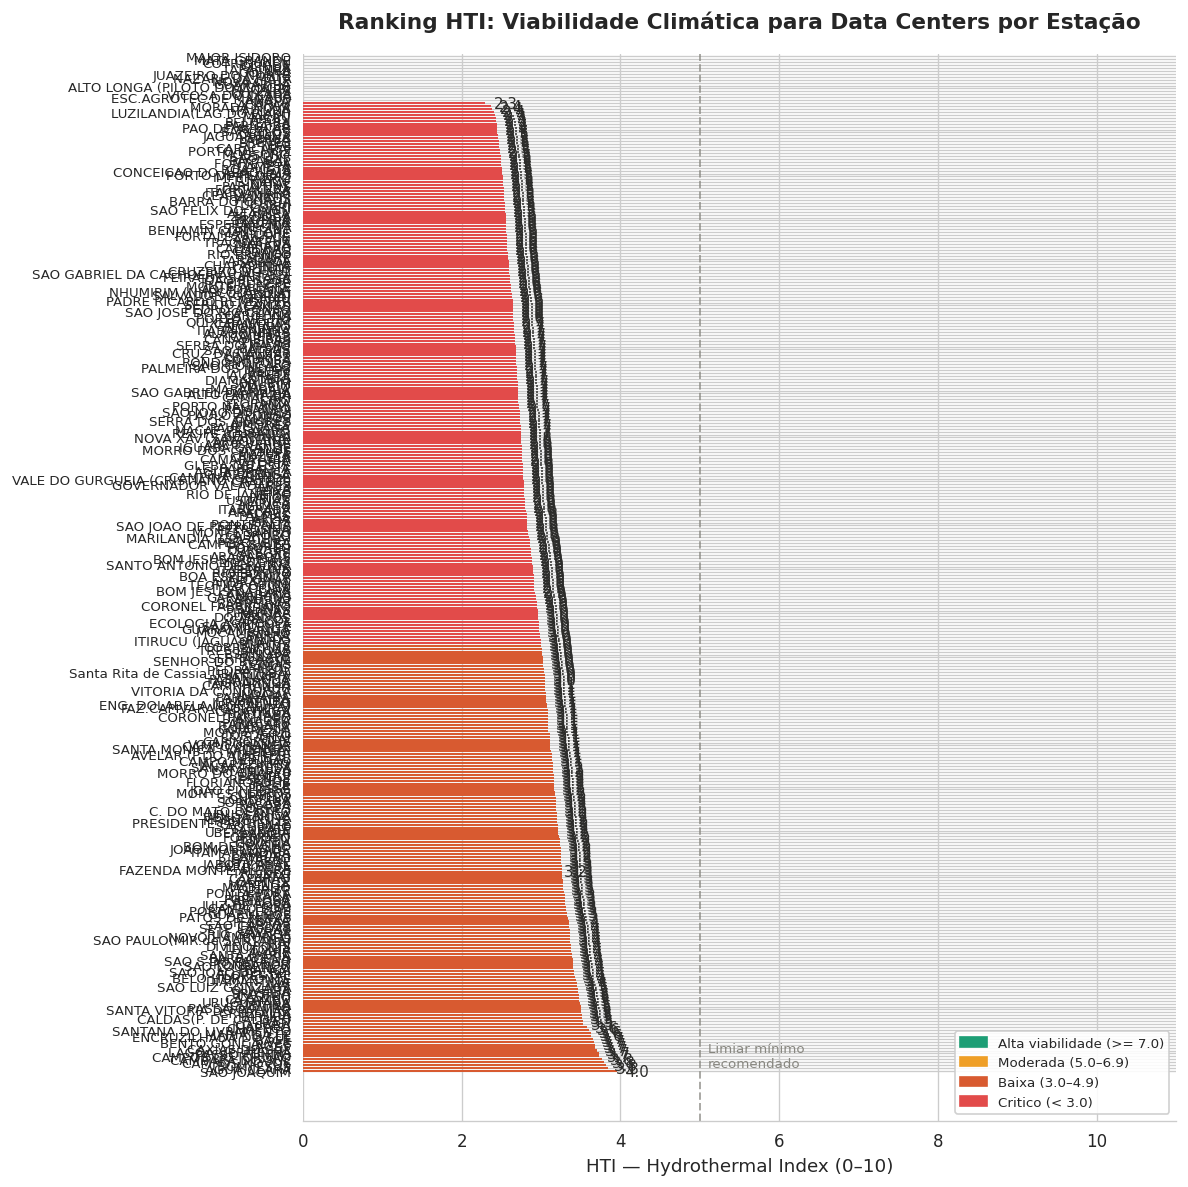


✅ HTI_ranking_por_estacao.png
Autor: Augusto dos Santos Dalosta


In [ ]:
def cor_hti(hti):
    if hti >= 7.0:   return '#1D9E75'
    elif hti >= 5.0: return '#EF9F27'
    elif hti >= 3.0: return '#D85A30'
    else:            return '#E24B4A'

# Usar o DataFrame 'ranking' que já contém o HTI médio por estação e está classificado.
df_ranked_for_plot = ranking.copy()

# Garantir que a coluna 'Cidade' esteja presente em df_ranked_for_plot para plotagem
# O 'station_city_map' está disponível a partir da execução anterior (célula X14Gw9iwSSG3)
if 'station_city_map' in globals():
    df_ranked_for_plot['Cidade'] = df_ranked_for_plot['Estacao'].map(station_city_map)
    df_ranked_for_plot['Cidade'] = df_ranked_for_plot['Cidade'].fillna(df_ranked_for_plot['Estacao'])
else:
    print("Aviso: 'station_city_map' não encontrado. Usando 'Estacao' como fallback para 'Cidade'.")
    df_ranked_for_plot['Cidade'] = df_ranked_for_plot['Estacao']


df_ranked_for_plot['cor'] = df_ranked_for_plot['HTI_Medio'].apply(cor_hti)

fig, ax = plt.subplots(figsize=(10, 10)) # Aumentei o tamanho para melhor visualização das estações
bars = ax.barh(df_ranked_for_plot['Cidade'].astype(str), df_ranked_for_plot['HTI_Medio'], color=df_ranked_for_plot['cor'], height=0.75, edgecolor='none')

ax.axvline(x=5.0, color='#888780', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(5.1, 0.5, 'Limiar mínimo\nrecomendado', fontsize=8, color='#888780', va='bottom')

for bar, val in zip(bars, df_ranked_for_plot['HTI_Medio']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9, color='#2C2C2A')

legend_elements = [
    mpatches.Patch(color='#1D9E75', label='Alta viabilidade (>= 7.0)'),
    mpatches.Patch(color='#EF9F27', label='Moderada (5.0–6.9)'),
    mpatches.Patch(color='#D85A30', label='Baixa (3.0–4.9)'),
    mpatches.Patch(color='#E24B4A', label='Critico (< 3.0)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)

ax.set_xlim(0, 11)
ax.set_xlabel('HTI — Hydrothermal Index (0–10)', fontsize=11)
ax.set_title('Ranking HTI: Viabilidade Climática para Data Centers por Estação', # Ajustado o título
             fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=8) # Reduzi o tamanho da fonte do rótulo do eixo y

plt.tight_layout()
plt.savefig('HTI_ranking_por_estacao.png', bbox_inches='tight', dpi=150) # Ajustei o nome do arquivo
plt.show()
print("\n✅ HTI_ranking_por_estacao.png")
print("Autor: Augusto dos Santos Dalosta")

In [ ]:
import re
import os

# Create a dictionary to store the mapping from station code to city name
station_city_map = {}

if 'csv_files' in globals() and csv_files and 'drive_folder_path_extracted' in globals():
    for selected_csv_file in csv_files:
        full_csv_path = os.path.join(drive_folder_path_extracted, selected_csv_file)
        try:
            with open(full_csv_path, 'r', encoding='latin1') as f:
                # Read the first few lines to get metadata
                header_lines = [f.readline() for _ in range(10)] # Read first 10 lines

                station_code = None;
                city_name = None

                for line in header_lines:
                    if "Codigo Estacao:" in line:
                        station_code_match = re.search(r'Codigo Estacao: (\d+)', line)
                        if station_code_match:
                            station_code = station_code_match.group(1).strip()
                    if "Nome:" in line:
                        city_name_match = re.search(r'Nome: (.+)', line)
                        if city_name_match:
                            city_name = city_name_match.group(1).strip()
                    if station_code and city_name:
                        break # Found both, no need to read more lines

                if station_code and city_name:
                    station_city_map[station_code] = city_name
                else:
                    print(f"Não foi possível extrair o código da estação ou o nome da cidade de {selected_csv_file}")

        except Exception as e:
            print(f"Erro ao processar o cabeçalho de {selected_csv_file}: {e}")

print(f"✅ Mapeamento de {len(station_city_map)} estações para cidades criado.")

# Add 'Cidade' column to the ranking DataFrame
if 'ranking' in globals():
    ranking['Cidade'] = ranking['Estacao'].map(station_city_map)
    # Fallback to station code if city name not found for some reason
    ranking['Cidade'] = ranking['Cidade'].fillna(ranking['Estacao'])
    print("✅ Coluna 'Cidade' adicionada ao DataFrame 'ranking'.")
    display(ranking.head())
else:
    print("Erro: DataFrame 'ranking' não encontrado. Certifique-se de que a célula de cálculo do HTI foi executada.")

✅ Mapeamento de 405 estações para cidades criado.
✅ Coluna 'Cidade' adicionada ao DataFrame 'ranking'.


,Estacao,HTI_Medio,Classificacao,Cidade
1,83920,3.956030,Baixa viabilidade,SAO JOAQUIM
2,83615,3.840000,Baixa viabilidade,AGUA CLARA
3,83919,3.813757,Baixa viabilidade,BOM JESUS
4,83887,3.797584,Baixa viabilidade,CAMPOS NOVOS
5,83946,3.764428,Baixa viabilidade,CAMBARA DO SUL


In [ ]:
# 5. GRÁFICO 2 — Heatmap das dimensões por cidade

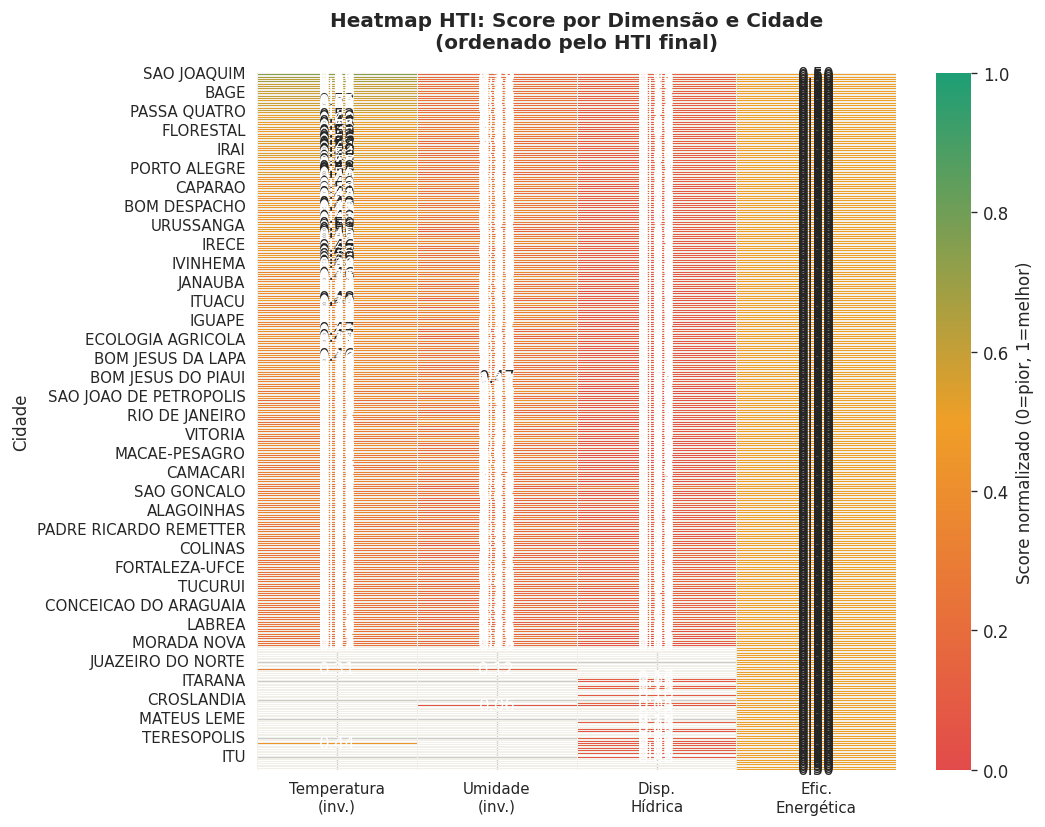

✅ HTI_heatmap.png
  Autor: Augusto dos Santos Dalosta


In [ ]:
# 1. Agrupar os dados por estação e calcular a média das dimensões normalizadas e do HTI
df_aggregated = df.groupby('Estacao').agg(
    {
        'N_Temperatura': 'mean',
        'N_Umidade': 'mean',
        'N_Agua': 'mean',
        'N_Energia': 'mean',
        'HTI': 'mean',
        'TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C': 'mean', # Adiciona a temperatura média ao df_aggregated
        'UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%': 'mean' # Adiciona a umidade relativa média ao df_aggregated
    }
).reset_index()

# 2. Mapear os códigos das estações para os nomes das cidades
df_aggregated['Cidade'] = df_aggregated['Estacao'].map(station_city_map)
# Lidar com estações que podem não ter um mapeamento de cidade (usar o código da estação como fallback)
df_aggregated['Cidade'] = df_aggregated['Cidade'].fillna(df_aggregated['Estacao'])

# 3. Preparar os dados para o heatmap: ordenar pelo HTI e definir a cidade como índice
df_heat = df_aggregated.sort_values('HTI', ascending=False).set_index('Cidade')
heat_data = df_heat[['N_Temperatura', 'N_Umidade', 'N_Agua', 'N_Energia']]
heat_data.columns = ['Temperatura\n(inv.)', 'Umidade\n(inv.)', 'Disp.\nHídrica', 'Efic.\nEnergética']

cmap = LinearSegmentedColormap.from_list('hti', ['#E24B4A', '#EF9F27', '#1D9E75'])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    heat_data, annot=True, fmt='.2f',
    cmap=cmap, vmin=0, vmax=1,
    linewidths=0.5, linecolor='#F1EFE8',
    ax=ax, cbar_kws={'label': 'Score normalizado (0=pior, 1=melhor)'}
)
ax.set_title('Heatmap HTI: Score por Dimensão e Cidade\n(ordenado pelo HTI final)',
             fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig('HTI_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ HTI_heatmap.png")
print("  Autor: Augusto dos Santos Dalosta")


In [ ]:
# 6. GRÁFICO 3 — Scatter Temperatura x Umidade

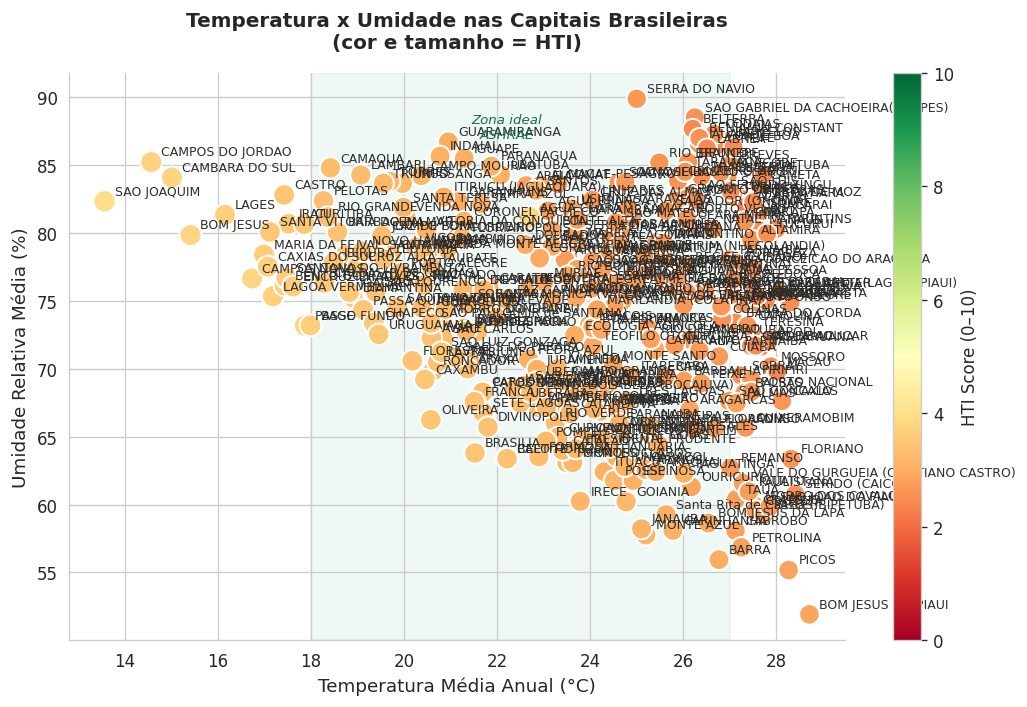

✅ HTI_scatter.png
  Autor: Augusto dos Santos Dalosta


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# Aggregate data for the scatter plot, calculating mean temperature, humidity, and HTI per station
df_scatter_data = df.groupby('Estacao').agg(
    Temp_Media=('TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C', 'mean'),
    Umidade_Media=('UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%', 'mean'),
    HTI=('HTI', 'mean')
).reset_index()

# Map station codes to city names
df_scatter_data['Cidade'] = df_scatter_data['Estacao'].map(station_city_map)
# Fallback to station code if city name not found
df_scatter_data['Cidade'] = df_scatter_data['Cidade'].fillna(df_scatter_data['Estacao'])

# Remove rows where Temp_Media, Umidade_Media, or HTI might be NaN after aggregation
df_scatter_data.dropna(subset=['Temp_Media', 'Umidade_Media', 'HTI', 'Cidade'], inplace=True)

scatter = ax.scatter(
    df_scatter_data['Temp_Media'], df_scatter_data['Umidade_Media'],
    c=df_scatter_data['HTI'], cmap='RdYlGn',
    s=df_scatter_data['HTI'] * 25 + 80,
    edgecolors='white', linewidth=1.2,
    vmin=0, vmax=10, zorder=3
)

for _, row in df_scatter_data.iterrows():
    ax.annotate(
        row['Cidade'],
        (row['Temp_Media'], row['Umidade_Media']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=7.5, color='#2C2C2A'
    )

ax.axvspan(18, 27, alpha=0.07, color='#1D9E75', zorder=0)
ax.text(22.2, 87, 'Zona ideal\nASHRAE', fontsize=8, color='#0F6E56', ha='center', style='italic')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('HTI Score (0–10)', fontsize=10)

ax.set_xlabel('Temperatura Média Anual (°C)', fontsize=11)
ax.set_ylabel('Umidade Relativa Média (%)', fontsize=11)
ax.set_title('Temperatura x Umidade nas Capitais Brasileiras\n(cor e tamanho = HTI)',
             fontsize=12, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('HTI_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ HTI_scatter.png")
print("  Autor: Augusto dos Santos Dalosta")

In [ ]:
# Exibir as 5 cidades com melhor HTI
top_5_cities = df_aggregated.sort_values(by='HTI', ascending=False).head(5)
display(top_5_cities[['Cidade', 'HTI']])

,Cidade,HTI
382,SAO JOAQUIM,3.956030
285,AGUA CLARA,3.840000
381,BOM JESUS,3.813757
370,CAMPOS NOVOS,3.797584
389,CAMBARA DO SUL,3.764428


In [ ]:
# 7. ANÁLISE DE SENSIBILIDADE

In [ ]:
print("\n" + "=" * 55)
print("  ANÁLISE DE SENSIBILIDADE — VARIAÇÃO DOS PESOS")
print("=" * 55)

cenarios = {
    'Base (30/25/25/20)':               (0.30, 0.25, 0.25, 0.20),
    'Foco Temperatura (40/20/20/20)':   (0.40, 0.20, 0.20, 0.20),
    'Foco Água (20/20/40/20)':          (0.20, 0.20, 0.40, 0.20),
    'Foco Energia (20/20/20/40)':       (0.20, 0.20, 0.20, 0.40),
    'Igualitário (25/25/25/25)':        (0.25, 0.25, 0.25, 0.25)
}

# Ensure df has 'Cidade' column for printing results correctly
# Assuming 'station_city_map' is available from previous cells
df['Cidade'] = df['Estacao'].map(station_city_map)
df['Cidade'] = df['Cidade'].fillna(df['Estacao'])

for nome, (pt, pu, pa, pe) in cenarios.items():
    # Calculate HTI for each scenario, handling potential NaN values in N_ columns
    hti_scenario = (
        df['N_Temperatura'].fillna(0) * pt +
        df['N_Umidade'].fillna(0) * pu +
        df['N_Agua'].fillna(0) * pa +
        df['N_Energia'].fillna(0) * pe
    ) * 10

    # Aggregate HTI by station before finding top cities
    hti_aggregated_by_station = hti_scenario.groupby(df['Estacao']).mean()

    # Create a temporary DataFrame to get 'Cidade' names for the aggregated HTI
    temp_df = pd.DataFrame({
        'HTI': hti_aggregated_by_station,
        'Estacao': hti_aggregated_by_station.index
    }).reset_index(drop=True)
    temp_df['Cidade'] = temp_df['Estacao'].map(station_city_map)
    temp_df['Cidade'] = temp_df['Cidade'].fillna(temp_df['Estacao'])

    # Sort and get the top 3 cities based on the scenario's HTI
    top3_cities_df = temp_df.sort_values(by='HTI', ascending=False).head(3)
    top3 = top3_cities_df['Cidade'].tolist()

    print(f"\n  {nome}")
    print(f"  Top 3: {' | '.join(top3)}")

print("\n✅ Análise de sensibilidade concluída.")
print("  Autor: Augusto dos Santos Dalosta")


  ANÁLISE DE SENSIBILIDADE — VARIAÇÃO DOS PESOS

  Base (30/25/25/20)
  Top 3: SAO JOAQUIM | CAMPOS NOVOS | BOM JESUS

  Foco Temperatura (40/20/20/20)
  Top 3: SAO JOAQUIM | BOM JESUS | CAMPOS NOVOS

  Foco Água (20/20/40/20)
  Top 3: SAO JOAQUIM | CAMPOS NOVOS | BOM JESUS

  Foco Energia (20/20/20/40)
  Top 3: SAO JOAQUIM | CAMPOS NOVOS | BOM JESUS

  Igualitário (25/25/25/25)
  Top 3: SAO JOAQUIM | CAMPOS NOVOS | BOM JESUS

✅ Análise de sensibilidade concluída.
  Autor: Augusto dos Santos Dalosta


In [ ]:
# 8. EXPORTAR CSV

In [ ]:
print("\n" + "=" * 55)
print("  EXPORTANDO ANÁLISE DE SENSIBILIDADE")
print("  Autor: Augusto dos Santos Dalosta")
print("=" * 55)

cenarios = {
    'Base (30/25/25/20)':               (0.30, 0.25, 0.25, 0.20),
    'Foco Temperatura (40/20/20/20)':   (0.40, 0.20, 0.20, 0.20),
    'Foco Água (20/20/40/20)':          (0.20, 0.20, 0.40, 0.20),
    'Foco Energia (20/20/20/40)':       (0.20, 0.20, 0.20, 0.40),
    'Igualitário (25/25/25/25)':        (0.25, 0.25, 0.25, 0.25)
}

all_sensitivity_results = []

for nome_cenario, (pt, pu, pa, pe) in cenarios.items():
    hti_scenario = (
        df['N_Temperatura'].fillna(0) * pt +
        df['N_Umidade'].fillna(0) * pu +
        df['N_Agua'].fillna(0) * pa +
        df['N_Energia'].fillna(0) * pe
    ) * 10

    hti_aggregated_by_station = hti_scenario.groupby(df['Estacao']).mean()

    temp_df = pd.DataFrame({
        'HTI': hti_aggregated_by_station,
        'Estacao': hti_aggregated_by_station.index
    }).reset_index(drop=True)
    temp_df['Cidade'] = temp_df['Estacao'].map(station_city_map)
    temp_df['Cidade'] = temp_df['Cidade'].fillna(temp_df['Estacao'])

    top3_cities_df = temp_df.sort_values(by='HTI', ascending=False).head(3)

    result_row = {
        'Cenario': nome_cenario,
        'Top1_Cidade': top3_cities_df.iloc[0]['Cidade'] if not top3_cities_df.empty else None,
        'Top1_HTI': top3_cities_df.iloc[0]['HTI'] if not top3_cities_df.empty else None,
        'Top2_Cidade': top3_cities_df.iloc[1]['Cidade'] if len(top3_cities_df) > 1 else None,
        'Top2_HTI': top3_cities_df.iloc[1]['HTI'] if len(top3_cities_df) > 1 else None,
        'Top3_Cidade': top3_cities_df.iloc[2]['Cidade'] if len(top3_cities_df) > 2 else None,
        'Top3_HTI': top3_cities_df.iloc[2]['HTI'] if len(top3_cities_df) > 2 else None,
    }
    all_sensitivity_results.append(result_row)

sensitivity_df = pd.DataFrame(all_sensitivity_results)

output_csv_path = 'analise_sensibilidade_hti.csv'
sensitivity_df.to_csv(output_csv_path, index=False, decimal=',', sep=';')

print(f"✅ Resultados da análise de sensibilidade exportados para: {output_csv_path}")
display(sensitivity_df)


  EXPORTANDO ANÁLISE DE SENSIBILIDADE
  Autor: Augusto dos Santos Dalosta
✅ Resultados da análise de sensibilidade exportados para: analise_sensibilidade_hti.csv


,Cenario,Top1_Cidade,Top1_HTI,Top2_Cidade,Top2_HTI,Top3_Cidade,Top3_HTI
0,Base (30/25/25/20),SAO JOAQUIM,3.954996,CAMPOS NOVOS,3.788271,BOM JESUS,3.726697
1,Foco Temperatura (40/20/20/20),SAO JOAQUIM,4.551703,BOM JESUS,4.229654,CAMPOS NOVOS,4.226567
2,Foco Água (20/20/40/20),SAO JOAQUIM,3.329313,CAMPOS NOVOS,3.283830,BOM JESUS,3.168605
3,Foco Energia (20/20/20/40),SAO JOAQUIM,4.067070,CAMPOS NOVOS,3.981629,BOM JESUS,3.919284
4,Igualitário (25/25/25/25),SAO JOAQUIM,3.833838,CAMPOS NOVOS,3.727036,BOM JESUS,3.649105


/tmp/ipykernel_14866/4199073270.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


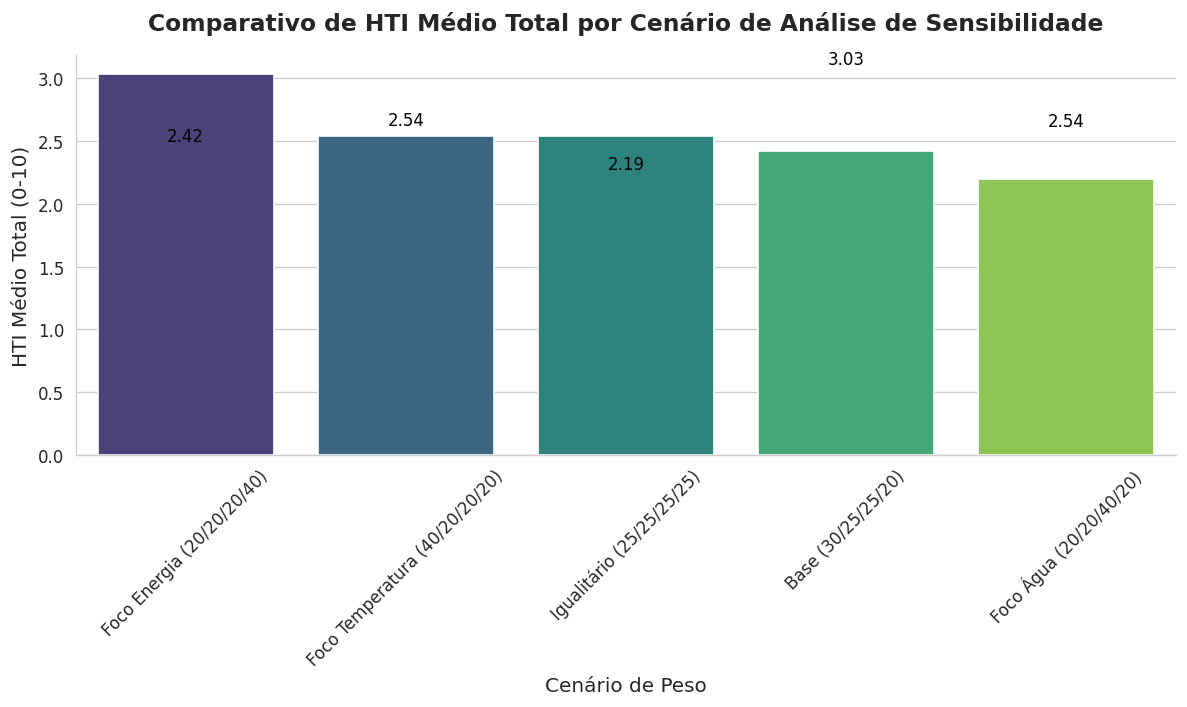

✅ HTI_mean_comparison_scenarios.png
  Autor: Augusto dos Santos Dalosta


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recalcular o HTI médio para cada cenário, considerando todas as estações
mean_hti_per_scenario = {}

for nome_cenario, (pt, pu, pa, pe) in cenarios.items():
    hti_scenario = (
        df['N_Temperatura'].fillna(0) * pt +
        df['N_Umidade'].fillna(0) * pu +
        df['N_Agua'].fillna(0) * pa +
        df['N_Energia'].fillna(0) * pe
    ) * 10

    # Calcular a média de HTI para todas as estações neste cenário
    mean_hti_per_scenario[nome_cenario] = hti_scenario.mean()

# Converter o dicionário para um DataFrame para fácil plotagem
df_mean_hti_scenarios = pd.DataFrame(
    mean_hti_per_scenario.items(),
    columns=['Cenário', 'HTI Médio Total']
)

# Ordenar para melhor visualização, se desejar
df_mean_hti_scenarios = df_mean_hti_scenarios.sort_values(
    by='HTI Médio Total', ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x='Cenário', y='HTI Médio Total', data=df_mean_hti_scenarios,
    palette='viridis', ax=ax
)

ax.set_title(
    'Comparativo de HTI Médio Total por Cenário de Análise de Sensibilidade',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Cenário de Peso', fontsize=12)
ax.set_ylabel('HTI Médio Total (0-10)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)

# Adicionar os valores nas barras
for index, row in df_mean_hti_scenarios.iterrows():
    ax.text(
        index, row['HTI Médio Total'] + 0.05, f"{row['HTI Médio Total']:.2f}",
        color='black', ha="center", va='bottom', fontsize=10
    )

plt.tight_layout()
plt.savefig('HTI_mean_comparison_scenarios.png', bbox_inches='tight', dpi=150)
plt.show()

print("✅ HTI_mean_comparison_scenarios.png")
print("  Autor: Augusto dos Santos Dalosta")

## 9. Conclusão e Visualização Geográfica

In [ ]:
import re
import pandas as pd
import os

print("Extraindo dados de geolocalização das estações...")
print("Autor: Augusto dos Santos Dalosta")
station_metadata_list = []

# Certifique-se de que 'csv_files' e 'drive_folder_path_extracted' estão definidos
if 'csv_files' in globals() and csv_files and 'drive_folder_path_extracted' in globals():
    for selected_csv_file in csv_files:
        full_csv_path = os.path.join(drive_folder_path_extracted, selected_csv_file)
        try:
            with open(full_csv_path, 'r', encoding='latin1') as f:
                header_lines = [f.readline() for _ in range(10)] # Ler as primeiras 10 linhas

                station_code = None
                city_name = None
                latitude = None
                longitude = None

                for line in header_lines:
                    if "Codigo Estacao:" in line:
                        station_code_match = re.search(r'Codigo Estacao: (\d+)', line)
                        if station_code_match:
                            station_code = station_code_match.group(1).strip()
                    if "Nome:" in line:
                        city_name_match = re.search(r'Nome: (.+)', line)
                        if city_name_match:
                            city_name = city_name_match.group(1).strip()
                    if "Latitude:" in line:
                        latitude_match = re.search(r'Latitude: (-?\d+\.?\d*)', line)
                        if latitude_match:
                            latitude = float(latitude_match.group(1).strip())
                    if "Longitude:" in line:
                        longitude_match = re.search(r'Longitude: (-?\d+\.?\d*)', line)
                        if longitude_match:
                            longitude = float(longitude_match.group(1).strip())

                    if station_code and city_name and latitude is not None and longitude is not None:
                        break # Encontrou todos os dados necessários, pode parar de ler o cabeçalho

                if station_code: # Adicionar mesmo que alguns dados (cidade/lat/lon) estejam ausentes
                    station_metadata_list.append({
                        'Estacao': station_code,
                        'Cidade': city_name if city_name else station_code, # Usar código como fallback
                        'Latitude': latitude,
                        'Longitude': longitude
                    })

        except Exception as e:
            print(f"Erro ao processar o cabeçalho de {selected_csv_file}: {e}")

    station_geo_df = pd.DataFrame(station_metadata_list)

    # Mesclar com o DataFrame 'ranking'
    # Usar 'Cidade' do station_geo_df para garantir consistência e evitar NaNs
    ranking = ranking.drop(columns=['Cidade'], errors='ignore') # Remover coluna 'Cidade' existente se houver
    ranking = ranking.merge(station_geo_df[['Estacao', 'Cidade', 'Latitude', 'Longitude']], on='Estacao', how='left')

    # Mesclar com o DataFrame 'df_aggregated'
    # Remover a coluna 'Cidade' existente de df_aggregated para evitar conflitos na mesclagem,
    # pois a coluna 'Cidade' de station_geo_df será usada.
    df_aggregated = df_aggregated.drop(columns=['Cidade'], errors='ignore')

    # Realizar a mesclagem para adicionar as colunas 'Cidade', 'Latitude' e 'Longitude'
    # A coluna 'Cidade' será atualizada com os nomes da cidade do station_geo_df
    df_aggregated = df_aggregated.merge(
        station_geo_df[['Estacao', 'Cidade', 'Latitude', 'Longitude']],
        on='Estacao',
        how='left'
    )

    # Verificação robusta: se Latitude/Longitude ainda estiverem faltando (ex: por problemas na mesclagem)
    if 'Latitude' not in df_aggregated.columns or 'Longitude' not in df_aggregated.columns:
        print("Aviso: 'Latitude' ou 'Longitude' não foram adicionadas via merge. Tentando mapeamento explícito.")
        df_aggregated['Latitude'] = df_aggregated['Estacao'].map(station_geo_df.set_index('Estacao')['Latitude'])
        df_aggregated['Longitude'] = df_aggregated['Estacao'].map(station_geo_df.set_index('Estacao')['Longitude'])
        # Se 'Cidade' também estiver faltando ou incorreta, atualiza via mapeamento
        if 'Cidade' not in df_aggregated.columns or df_aggregated['Cidade'].isnull().all():
             df_aggregated['Cidade'] = df_aggregated['Estacao'].map(station_geo_df.set_index('Estacao')['Cidade']).fillna(df_aggregated['Estacao'])

    print("✅ Dados de geolocalização extraídos e mesclados com 'ranking' e 'df_aggregated'.")
    display(ranking.head())
    print("Colunas de df_aggregated após merge/map:", df_aggregated.columns) # Adicionado para depuração
else:
    print("Erro: Variáveis 'csv_files' ou 'drive_folder_path_extracted' não encontradas ou vazias.")

Extraindo dados de geolocalização das estações...
Autor: Augusto dos Santos Dalosta
Aviso: 'Latitude' ou 'Longitude' não foram adicionadas via merge. Tentando mapeamento explícito.
✅ Dados de geolocalização extraídos e mesclados com 'ranking' e 'df_aggregated'.


,Estacao,HTI_Medio,Classificacao,Latitude_x,Longitude_x,Cidade,Latitude_y,Longitude_y
0,83920,3.956030,Baixa viabilidade,-28.275556,-49.934722,SAO JOAQUIM,-28.275556,-49.934722
1,83615,3.840000,Baixa viabilidade,-22.450000,-52.970000,AGUA CLARA,-22.450000,-52.970000
2,83919,3.813757,Baixa viabilidade,-28.669444,-50.441944,BOM JESUS,-28.669444,-50.441944
3,83887,3.797584,Baixa viabilidade,-27.383889,-51.216111,CAMPOS NOVOS,-27.383889,-51.216111
4,83946,3.764428,Baixa viabilidade,-29.049167,-50.149722,CAMBARA DO SUL,-29.049167,-50.149722


Colunas de df_aggregated após merge/map: Index(['Estacao', 'N_Temperatura', 'N_Umidade', 'N_Agua', 'N_Energia', 'HTI',
       'TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C',
       'UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%', 'Latitude_x', 'Longitude_x',
       'Cidade', 'Latitude_y', 'Longitude_y', 'Latitude', 'Longitude'],
      dtype='object')


### 9.1. Mapa Geográfico do HTI Médio por Estação

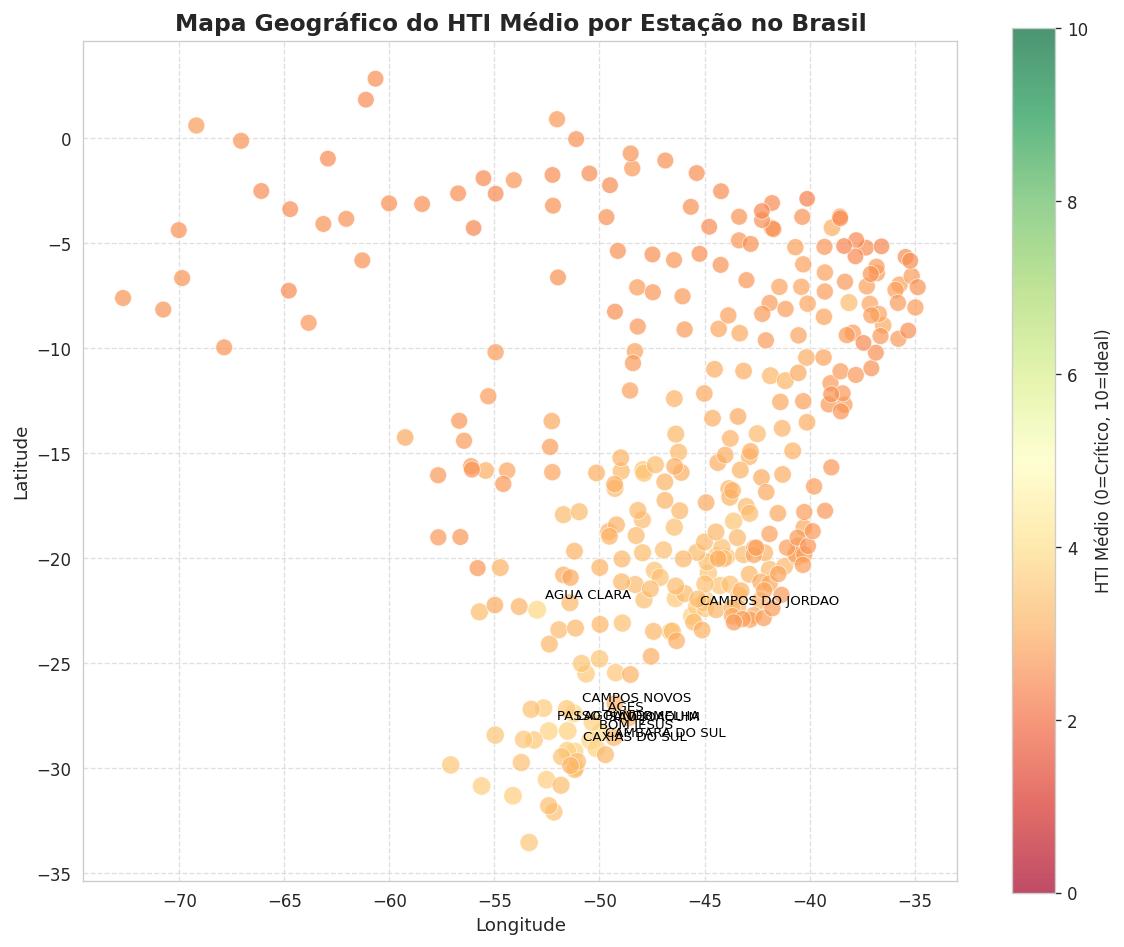

✅ HTI_geographic_map.png - Autor: Augusto dos Santos Dalosta


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

# Filtrar NaNs para coordenadas e HTI para plotagem
plot_df_hti = ranking.dropna(subset=['Latitude_x', 'Longitude_x', 'HTI_Medio'])

# Scatter plot para HTI
# Usar 'RdYlGn_r' para que vermelho seja HTI baixo (crítico) e verde seja HTI alto (ideal)
scatter_hti = ax.scatter(
    x=plot_df_hti['Longitude_x'],
    y=plot_df_hti['Latitude_x'],
    c=plot_df_hti['HTI_Medio'],
    cmap='RdYlGn',
    s=plot_df_hti['HTI_Medio'] * 20 + 50,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
    vmin=0, vmax=10
)

# Adicionar nomes das cidades para as 10 melhores localidades HTI para evitar muita poluição visual
top_n = 10
for _, row in plot_df_hti.sort_values(by='HTI_Medio', ascending=False).head(top_n).iterrows():
    ax.annotate(
        row['Cidade'],
        (row['Longitude_x'], row['Latitude_x']),
        textcoords="offset points", xytext=(5,5),
        ha='left', va='bottom', fontsize=8, color='black'
    )

cbar_hti = fig.colorbar(scatter_hti, ax=ax)
cbar_hti.set_label('HTI Médio (0=Crítico, 10=Ideal)', fontsize=10)

ax.set_title('Mapa Geográfico do HTI Médio por Estação no Brasil', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal', adjustable='box') # Manter a proporção para um mapa mais preciso

plt.tight_layout()
plt.savefig('HTI_geographic_map.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ HTI_geographic_map.png - Autor: Augusto dos Santos Dalosta")

### 9.2. Mapa Geográfico da Temperatura Média Anual por Estação

In [ ]:
print(df_aggregated.columns)

Index(['Estacao', 'N_Temperatura', 'N_Umidade', 'N_Agua', 'N_Energia', 'HTI',
       'TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C',
       'UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%', 'Cidade', 'Latitude',
       'Longitude'],
      dtype='object')


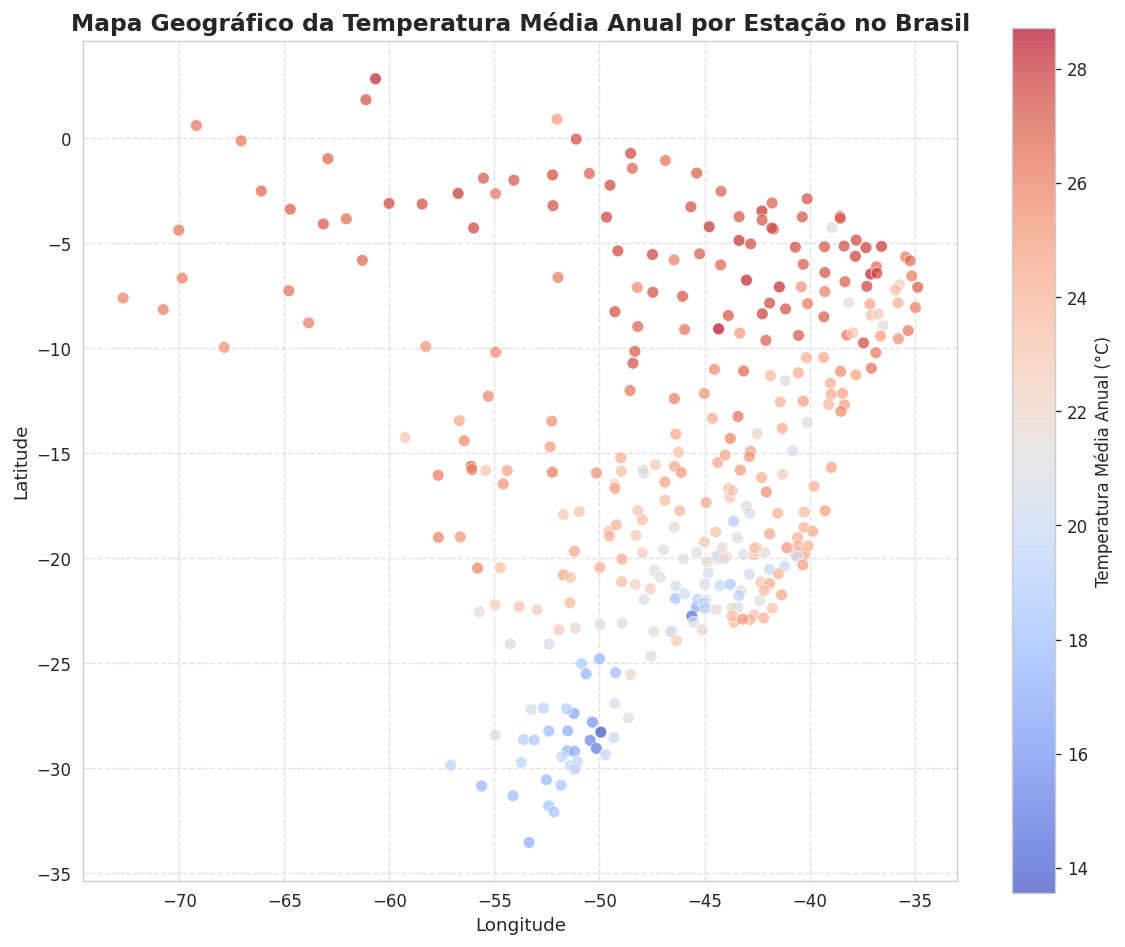

✅ Temperature_geographic_map.png - Autor: Augusto dos Santos Dalosta


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

# Filtrar NaNs para coordenadas e temperatura para plotagem
plot_df_temp = df_aggregated.dropna(subset=['Latitude', 'Longitude', 'TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C'])

# Scatter plot para Temperatura
scatter_temp = ax.scatter(
    x=plot_df_temp['Longitude'],
    y=plot_df_temp['Latitude'],
    c=plot_df_temp['TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C'],
    cmap='coolwarm', # Colormap adequado para temperatura
    s=50, # Tamanho fixo para pontos de temperatura
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

cbar_temp = fig.colorbar(scatter_temp, ax=ax)
cbar_temp.set_label('Temperatura Média Anual (°C)', fontsize=10)

ax.set_title('Mapa Geográfico da Temperatura Média Anual por Estação no Brasil', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('Temperature_geographic_map.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Temperature_geographic_map.png - Autor: Augusto dos Santos Dalosta")

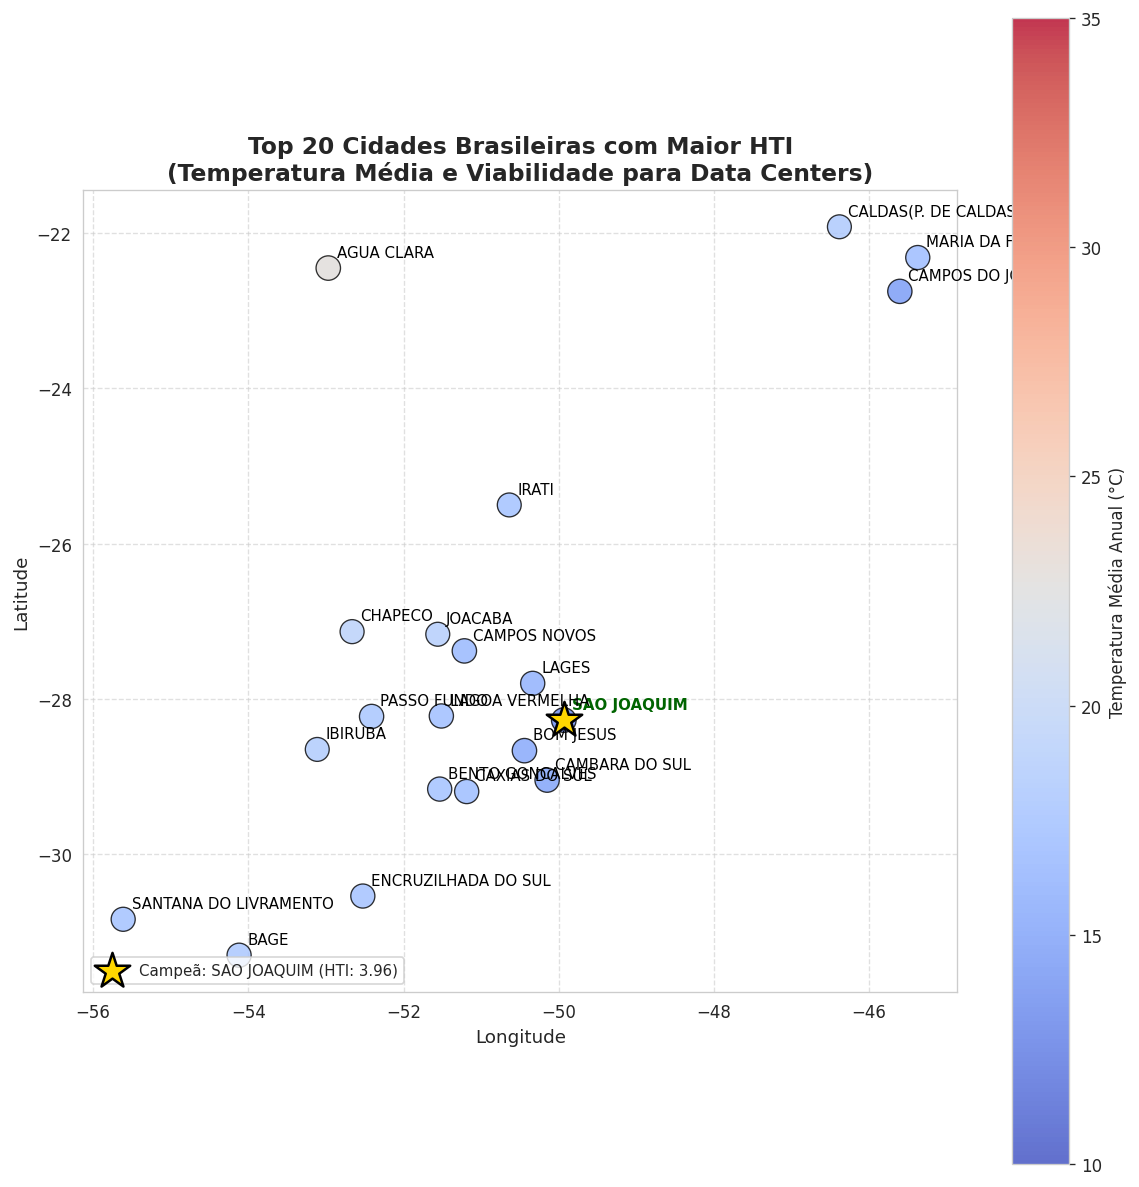


✅ Gráfico com as Top 20 cidades e a cidade campeã salvo: HTI_top20_cities_map.png - Autor: Augusto dos Santos Dalosta


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_aggregated has all necessary columns and is clean
# And that it's using the correct 'Cidade' column after recent merges
plot_df_ideal = df_aggregated.dropna(subset=['Latitude', 'Longitude', 'HTI', 'TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C', 'UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%', 'Cidade'])

# Sort by HTI and get the top 20 cities
plot_df_ideal = plot_df_ideal.sort_values(by='HTI', ascending=False).head(20).copy()

# Get the champion city (highest HTI)
# Ensure champion_city is a Series before accessing its elements
champion_city = plot_df_ideal.iloc[0]

fig, ax = plt.subplots(figsize=(10, 10))

# Scatter plot for the top cities
scatter = ax.scatter(
    x=plot_df_ideal['Longitude'],
    y=plot_df_ideal['Latitude'],
    c=plot_df_ideal['TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C'], # Color by Temperature
    cmap='coolwarm', # Colormap for temperature: cool for low, warm for high
    s=plot_df_ideal['HTI'] * 30 + 100, # Size by HTI to emphasize higher viability
    alpha=0.8,
    edgecolors='black', # Add edgecolors for better visibility
    linewidth=0.8,
    vmin=10, vmax=35 # Set temperature range appropriate for Brazil
)

# Add city names
for _, row in plot_df_ideal.iterrows():
    text_color = 'darkgreen' if row['Estacao'] == champion_city['Estacao'] else 'black'
    fontweight = 'bold' if row['Estacao'] == champion_city['Estacao'] else 'normal'
    ax.annotate(
        row['Cidade'],
        (row['Longitude'], row['Latitude']),
        textcoords="offset points", xytext=(5, 5),
        ha='left', va='bottom', fontsize=9, color=text_color, fontweight=fontweight
    )

# Highlight the champion city
ax.scatter(
    x=[champion_city['Longitude']],
    y=[champion_city['Latitude']],
    marker='*', # Star marker for champion
    s=500,       # Larger size for champion
    color='gold',
    edgecolors='black',
    linewidth=1.5,
    label=f"Campeã: {champion_city['Cidade']} (HTI: {champion_city['HTI']:.2f})",
    zorder=5 # Ensure star is on top
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Temperatura Média Anual (°C)', fontsize=10)

ax.set_title(
    'Top 20 Cidades Brasileiras com Maior HTI\n(Temperatura Média e Viabilidade para Data Centers)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal', adjustable='box')

ax.legend(loc='lower left', fontsize=9) # Add legend for champion city

plt.tight_layout()
plt.savefig('HTI_top20_cities_map.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n✅ Gráfico com as Top 20 cidades e a cidade campeã salvo: HTI_top20_cities_map.png - Autor: Augusto dos Santos Dalosta")

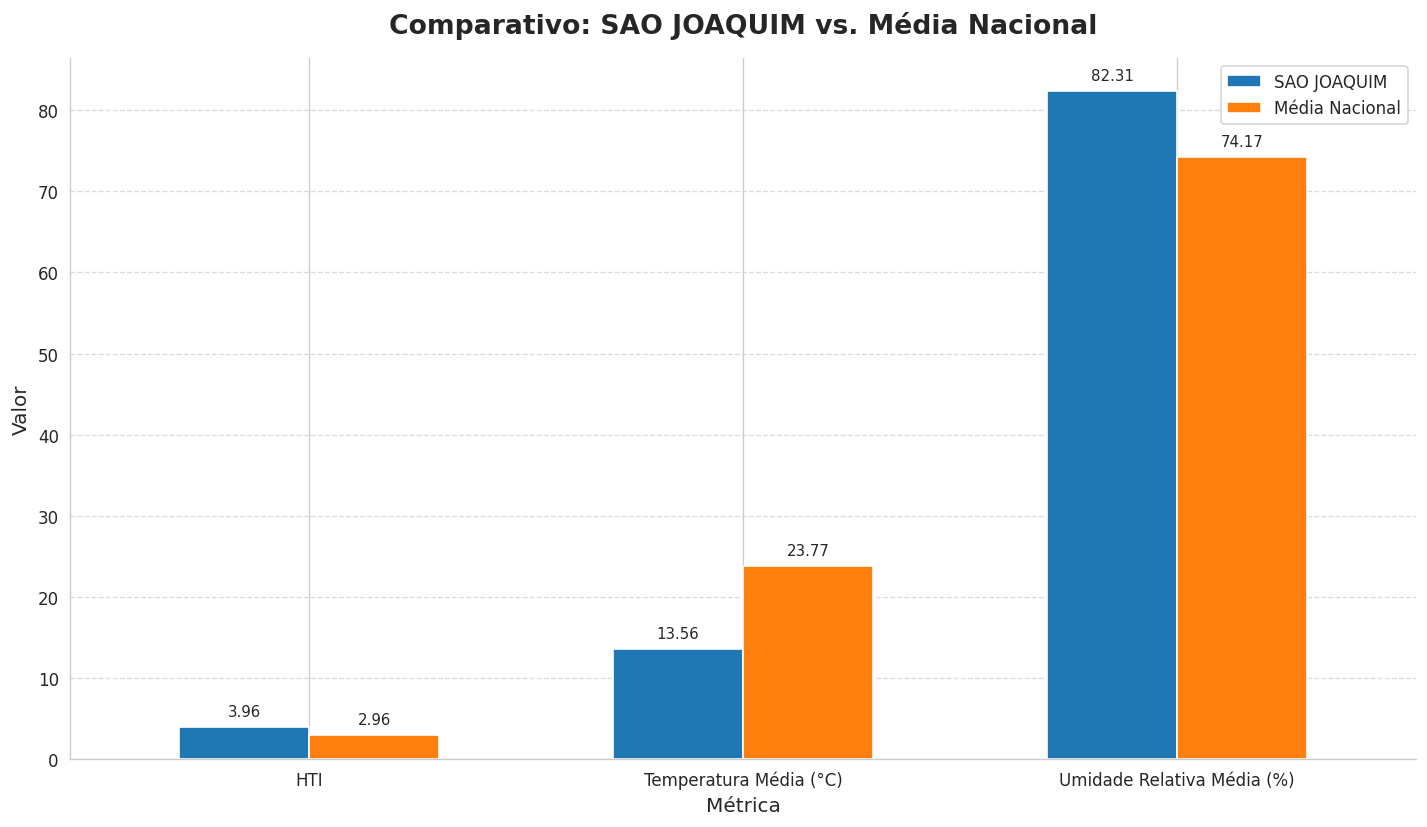


✅ Gráfico comparando SAO JOAQUIM com a média nacional salvo: comparativo_campea_nacional.png
Autor: Augusto dos Santos Dalosta


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calcular as médias nacionais para HTI, Temperatura e Umidade
# Certifique-se de ignorar NaNs no cálculo da média
national_avg_hti = df_aggregated['HTI'].mean()
national_avg_temp = df_aggregated['TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C'].mean()
national_avg_humidity = df_aggregated['UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%'].mean()

# 2. Obter os dados da cidade campeã
# `champion_city` já está disponível no kernel após a execução da célula anterior
champion_city_name = champion_city['Cidade']
champion_city_hti = champion_city['HTI']
champion_city_temp = champion_city['TEMPERATURA_MEDIA_COMPENSADA_MENSAL_C']
champion_city_humidity = champion_city['UMIDADE_RELATIVA_AR_MEDIA_MENSAL_%']

# 3. Criar um DataFrame para a comparação
comparison_data = {
    'Métrica': ['HTI', 'Temperatura Média (°C)', 'Umidade Relativa Média (%)'],
    champion_city_name: [champion_city_hti, champion_city_temp, champion_city_humidity],
    'Média Nacional': [national_avg_hti, national_avg_temp, national_avg_humidity]
}
comparison_df = pd.DataFrame(comparison_data)

# 4. Plotar o gráfico de barras
fig, ax = plt.subplots(figsize=(12, 7))

comparison_df.set_index('Métrica').plot(kind='bar', ax=ax, width=0.6)

ax.set_title(f'Comparativo: {champion_city_name} vs. Média Nacional', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Valor', fontsize=12)
ax.set_xlabel('Métrica', fontsize=12)
ax.tick_params(axis='x', rotation=0) # Manter os rótulos do eixo x na horizontal

# Adicionar valores nas barras para melhor leitura
for container in ax.containers:
    for i, p in enumerate(container.patches):
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points', fontsize=9)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('comparativo_campea_nacional.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n✅ Gráfico comparando {champion_city_name} com a média nacional salvo: comparativo_campea_nacional.png")
print("Autor: Augusto dos Santos Dalosta")

In [ ]:
print("# HTI - Hydrothermal Index")
print("# Copyright (c) [2026] [Augusto dos Santos Dalosta]")
print("# Todos os direitos reservados.")
print("# Este código é protegido pela Lei 9.609/98 e normas da Lei 9.610/98.")
print("# Proibida a cópia, reprodução ou distribuição sem autorização prévia.")

# HTI - Hydrothermal Index
# Copyright (c) [2026] [Augusto dos Santos Dalosta]
# Todos os direitos reservados.
# Este código é protegido pela Lei 9.609/98 e normas da Lei 9.610/98.
# Proibida a cópia, reprodução ou distribuição sem autorização prévia.
